In [1]:
import sys
import os
import glob
from pathlib import Path

sys.path.append(os.path.abspath('/home/users/zhiyi/PROJECTS_ANALYSIS'))

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt


In [60]:

FIGURE_DATA_DIR = Path('/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data')
FIGURES_DIR = Path('/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figures')

MET_GPKG = {
    'O3': '/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MetOffice/Monthly_Mean_Ozone_Gridded_-4374955293643276370.gpkg',
    'PM25': '/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MetOffice/Monthly_Mean_PM2p5_Gridded_3075619853497766146.gpkg',
}

MUSICA_DIR = '/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/regrid/regirdded_fv01'
MUSICA_FILES = (
    sorted(glob.glob(f'{MUSICA_DIR}/MUSICA_fv01_MUSICA_production3.2_BB.cam.h4.2017-12.nc'))
    + sorted(glob.glob(f'{MUSICA_DIR}/MUSICA_fv01_MUSICA_production3.2_BB.cam.h4.2018-??.nc'))
)
if not MUSICA_FILES:
    raise FileNotFoundError(f'No MUSICA files found in {MUSICA_DIR}')

NE_SHP = '/home/users/zhiyi/PROJECTS_ANALYSIS/shap_file/natural_earth/ne_10m_admin_1_states_provinces.shp'

SEASONS = {
    'DJF': (pd.Timestamp('2017-12-01', tz='UTC'), pd.Timestamp('2018-03-01', tz='UTC')),
    'MAM': (pd.Timestamp('2017-03-01', tz='UTC'), pd.Timestamp('2018-06-01', tz='UTC')),
    'JJA': (pd.Timestamp('2017-06-01', tz='UTC'), pd.Timestamp('2018-09-01', tz='UTC')),
    'SON': (pd.Timestamp('2017-09-01', tz='UTC'), pd.Timestamp('2018-12-01', tz='UTC')),
}

PANEL_ORDER = [
    ('a', 'O3', 'DJF'),
    ('b', 'O3', 'MAM'),
    ('c', 'O3', 'JJA'),
    ('d', 'O3', 'SON'),
    ('e', 'PM25', 'DJF'),
    ('f', 'PM25', 'MAM'),
    ('g', 'PM25', 'JJA'),
    ('h', 'PM25', 'SON'),
]

POLLUTANT_META = {
    'O3': {
        'var_name': 'O3',
        'factor_mus': 1e9 * 2.0,
        'title_name': 'O$_3$',
        'unit': 'µg/m³',
        'color_west': 'salmon',
        'color_east': 'salmon',
        'xmin': 40,
        'xmax': 85,
        'tick_step': 10,
    },
    'PM25': {
        'var_name': 'PM25',
        'factor_mus': 1e9,
        'title_name': 'PM$_{2.5}$',
        'unit': 'µg/m³',
        'color_west': 'limegreen',
        'color_east': 'royalblue',
        'xmin': 0,
        'xmax': None,
        'tick_step': 4,
    },
}


def calc_stats(x_sub, y_sub):
    mb = np.mean(y_sub - x_sub)
    rmse = np.sqrt(np.mean((y_sub - x_sub) ** 2))
    corr = np.corrcoef(x_sub, y_sub)[0, 1] if len(x_sub) > 1 else np.nan
    nmb = np.sum(y_sub - x_sub) / np.sum(x_sub) * 100.0
    return corr, mb, nmb, rmse


def load_uk_union():
    ne_admin1 = gpd.read_file(NE_SHP)
    if ne_admin1.crs is None or ne_admin1.crs.to_epsg() != 4326:
        ne_admin1 = ne_admin1.to_crs(epsg=4326)

    ne_uk = ne_admin1[ne_admin1['adm0_a3'].isin(['GBR', 'IMN'])]
    if hasattr(ne_uk, 'union_all'):
        return ne_uk.union_all()
    return ne_uk.unary_union


def load_ukaqr_grid(gpkg_path, start, end, uk_union):
    gdf = gpd.read_file(gpkg_path)
    gdf['stdTime'] = pd.to_datetime(gdf['stdTime'])
    gdf_sel = gdf.loc[(gdf['stdTime'] >= start) & (gdf['stdTime'] < end)].copy()

    gdf_avg = gdf_sel.groupby('gridID', as_index=False).agg(mean_avg=('mean', 'mean'))
    gdf_avg = gdf_avg.merge(
        gdf.drop_duplicates('gridID')[['gridID', 'geometry']],
        on='gridID',
        how='left',
    )
    gdf_avg = gpd.GeoDataFrame(gdf_avg, geometry='geometry')

    bounds = gdf_avg.geometry.bounds
    gdf_avg['lon'] = (bounds['minx'] + bounds['maxx']) / 2
    gdf_avg['lat'] = (bounds['miny'] + bounds['maxy']) / 2

    pivot = gdf_avg[['lon', 'lat', 'mean_avg']].pivot(
        index='lat',
        columns='lon',
        values='mean_avg',
    )

    lat_centers = pivot.index.values.astype(float)
    lon_centers = pivot.columns.values.astype(float)
    lonc2d, latc2d = np.meshgrid(lon_centers, lat_centers)

    points = gpd.GeoDataFrame(
        geometry=gpd.points_from_xy(lonc2d.ravel(), latc2d.ravel()),
        crs='EPSG:4326',
    )
    mask_land = points.within(uk_union).values.reshape(pivot.values.shape)
    met_masked = np.where(mask_land, pivot.values, np.nan)

    return {
        'lat_centers': lat_centers,
        'lon_centers': lon_centers,
        'lonc2d': lonc2d,
        'mask_land': mask_land,
        'met': met_masked,
    }


def open_musica_dataset():
    ds_mus = xr.open_mfdataset(MUSICA_FILES, combine='by_coords')
    lons_deg = xr.where(ds_mus['lon'] > 180, ds_mus['lon'] - 360, ds_mus['lon'])
    return ds_mus.assign_coords(lon=lons_deg).sortby('lon')


def musica_on_ukaqr_grid(ds_mus, pollutant, grid):
    meta = POLLUTANT_META[pollutant]
    var_sfc = (ds_mus[meta['var_name']] * meta['factor_mus']).isel(lev=-1)
    var_mean = var_sfc.mean(dim='time')
    var_on_met = var_mean.interp(
        lat=grid['lat_centers'],
        lon=grid['lon_centers'],
    )
    return np.where(grid['mask_land'], var_on_met.values, np.nan)


def build_scatter_data():
    uk_union = load_uk_union()
    ds_mus = open_musica_dataset()

    scatter_data = {}
    for label, pollutant, season in PANEL_ORDER:
        start, end = SEASONS[season]
        grid = load_ukaqr_grid(MET_GPKG[pollutant], start, end, uk_union)
        mus = musica_on_ukaqr_grid(ds_mus, pollutant, grid)

        x = grid['met'].ravel()
        y = mus.ravel()
        lon = grid['lonc2d'].ravel()
        valid = (~np.isnan(x)) & (~np.isnan(y))

        key = f'{pollutant.lower()}_{season.lower()}'
        scatter_data[key] = {
            'label': label,
            'pollutant': pollutant,
            'season': season,
            'x': x[valid],
            'y': y[valid],
            'lon': lon[valid],
        }

    ds_mus.close()
    return scatter_data


def draw_figure_s2(scatter_data):
    fig, axes = plt.subplots(2, 4, figsize=(13.6, 6.7))
    fig.subplots_adjust(left=0.045, right=0.995, bottom=0.075, top=0.94, wspace=0.06, hspace=0.38)

    for ax, (label, pollutant, season) in zip(axes.ravel(), PANEL_ORDER):
        key = f'{pollutant.lower()}_{season.lower()}'
        panel = scatter_data[key]
        meta = POLLUTANT_META[pollutant]

        x = panel['x']
        y = panel['y']
        lon = panel['lon']
        west = lon < -3.0
        east = lon >= -3.0

        xmin = meta['xmin']
        if meta['xmax'] is None:
            xmax = int(np.ceil(max(np.nanmax(x), np.nanmax(y)) / 2) * 2)
        else:
            xmax = meta['xmax']
        ticks = np.arange(xmin, xmax + 0.1, meta['tick_step'])

        ax.scatter(x[west], y[west], s=3, alpha=0.6, edgecolor='none', color=meta['color_west'])
        ax.scatter(x[east], y[east], s=3, alpha=0.6, edgecolor='none', color=meta['color_east'])

        xx = np.linspace(xmin, xmax, 200)
        ax.plot(xx, xx, ls='--', lw=0.7, color='black')
        ax.axvline(np.mean(x), ls=':', lw=0.75, color='grey')
        ax.axhline(np.mean(y), ls=':', lw=0.75, color='grey')

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(xmin, xmax)
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
        ax.set_aspect('equal', adjustable='box')
        ax.tick_params(axis='both', labelsize=15, length=2.5, pad=4)
        ax.set_xlabel('UKAQR', fontsize=14, labelpad=3)
        ax.set_ylabel('MUSICAv0', fontsize=14, labelpad=3)
        ax.set_title(f'{season} {meta["title_name"]} ({meta["unit"]})', fontsize=14, pad=8)
        ax.text(-0.10, 1.05, f'({label})', transform=ax.transAxes, ha='left', va='bottom', fontsize=14, fontweight='bold', clip_on=False)

        if pollutant == 'O3':
            corr, mb, nmb, rmse = calc_stats(x, y)
            stats_text = f'R: {corr:.2f}\nMB: {mb:.2f}\nNMB: {nmb:.2f}%\nRMSE: {rmse:.2f}'
            ax.text(0.48, 0.33, stats_text, transform=ax.transAxes, ha='left', va='top', fontsize=12)
        else:
            corr_w, mb_w, nmb_w, rmse_w = calc_stats(x[west], y[west])
            corr_e, mb_e, nmb_e, rmse_e = calc_stats(x[east], y[east])
            text_w = f'West of 3°W\nR: {corr_w:.2f}\nMB: {mb_w:.2f}\nNMB: {nmb_w:.2f}%\nRMSE: {rmse_w:.2f}'
            text_e = f'East of 3°W\nR: {corr_e:.2f}\nMB: {mb_e:.2f}\nNMB: {nmb_e:.2f}%\nRMSE: {rmse_e:.2f}'
            west_pos = (0.40, 0.95) if label == 'e' else (0.05, 0.88)
            ax.text(*west_pos, text_w, transform=ax.transAxes, ha='left', va='top', fontsize=10)
            ax.text(0.56, 0.33, text_e, transform=ax.transAxes, ha='left', va='top', fontsize=10)

    return fig, axes


/home/users/zhiyi/.conda/envs/plot_musica/lib/python3.9/site-packages/pyogrio/raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column stdTime, 2017-11-16T00:00:00.0Z, successfully parsed
  return ogr_read(
/home/users/zhiyi/.conda/envs/plot_musica/lib/python3.9/site-packages/pyogrio/raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column stdTime, 2017-11-16T00:00:00.0Z, successfully parsed
  return ogr_read(
/home/users/zhiyi/.conda/envs/plot_musica/lib/python3.9/site-packages/pyogrio/raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column stdTime, 2017-11-16T00:00:00.0Z, successfully parsed
  return ogr_read(
/home/users/zhiyi/.conda/envs/plot_musica/lib/python3.9/site-packages/pyogrio/raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column stdTime, 2017-11-16T00:00:00.0Z, successfully parsed
  return ogr_read(
/home/users/zhiyi/.conda/envs/plot_musica/lib/python3.9/site-packages/pyogrio/raw.py:198: RuntimeWarning

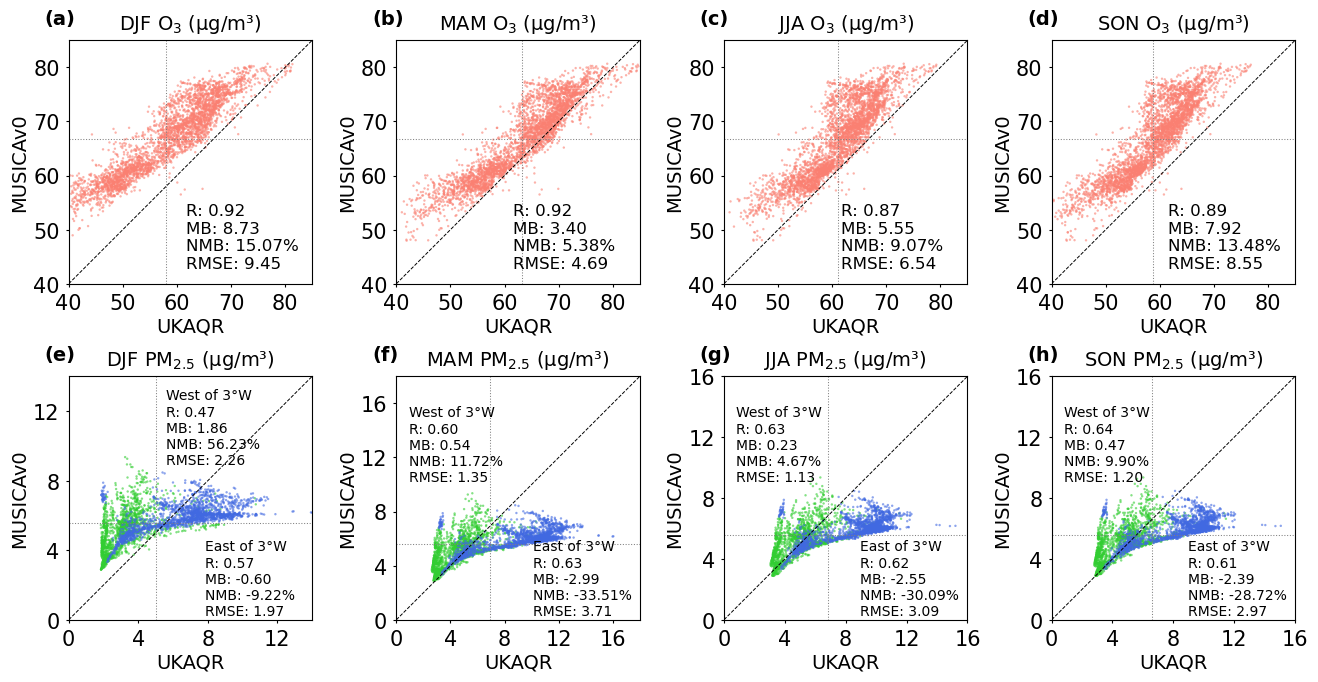

In [61]:
scatter_data = build_scatter_data()
fig, axes = draw_figure_s2(scatter_data)


In [4]:
FIGURE_DATA_DIR.mkdir(parents=True, exist_ok=True)
nc_out = FIGURE_DATA_DIR / 'FigureS2.nc'

coords = {}
data_vars = {}
for key, panel in scatter_data.items():
    dim = f'{key}_point'
    coords[dim] = np.arange(panel['x'].size)
    data_vars[f'{key}_UKAQR'] = ((dim,), panel['x'])
    data_vars[f'{key}_MUSICAv0'] = ((dim,), panel['y'])
    data_vars[f'{key}_lon'] = ((dim,), panel['lon'])

xr.Dataset(data_vars=data_vars, coords=coords).to_netcdf(nc_out)


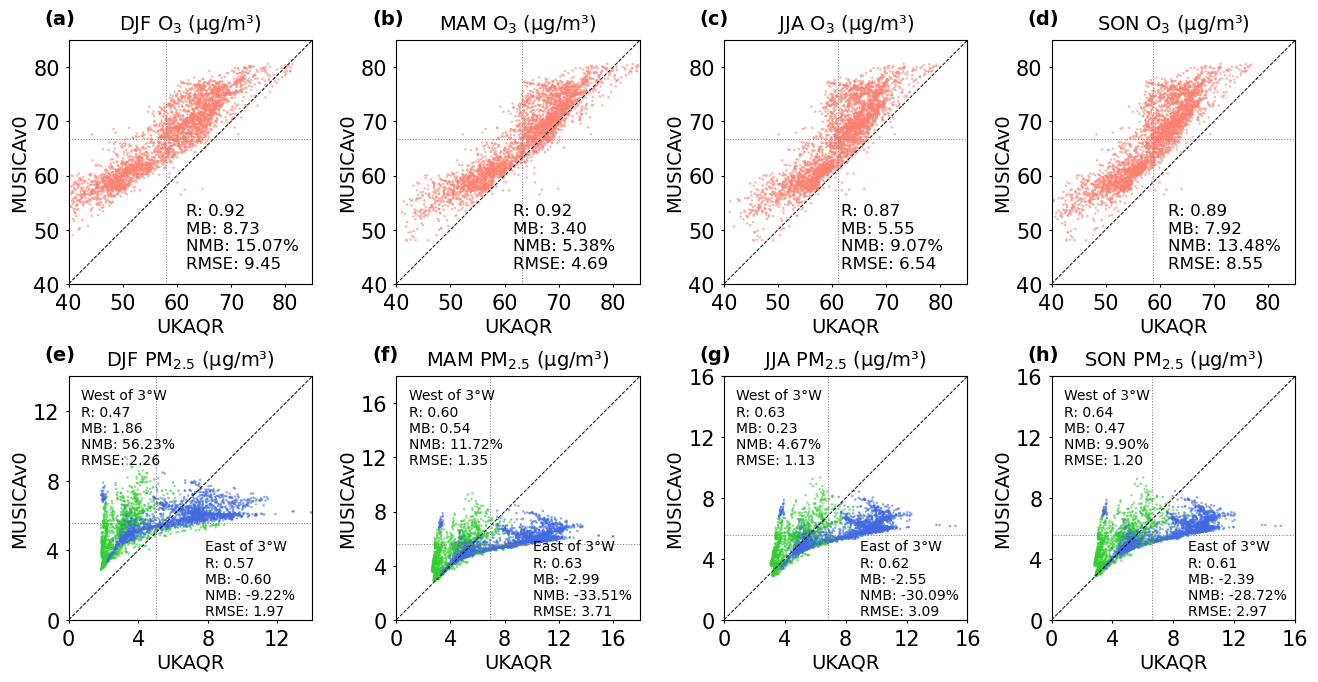

In [62]:
from pathlib import Path

FIGURE_DATA_DIR = Path('/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figure_data')
FIGURES_DIR = Path('/home/users/zhiyi/PROJECTS_ANALYSIS/P1_notebooks_revision/figures')
nc_in = FIGURE_DATA_DIR / 'FigureS2.nc'

if not nc_in.exists():
    raise FileNotFoundError(nc_in)

saved_ds = xr.open_dataset(nc_in)

panel_order = [
    ('a', 'O3', 'DJF'),
    ('b', 'O3', 'MAM'),
    ('c', 'O3', 'JJA'),
    ('d', 'O3', 'SON'),
    ('e', 'PM25', 'DJF'),
    ('f', 'PM25', 'MAM'),
    ('g', 'PM25', 'JJA'),
    ('h', 'PM25', 'SON'),
]

pollutant_meta = {
    'O3': {
        'title_name': 'O$_3$',
        'unit': 'µg/m³',
        'color_west': 'salmon',
        'color_east': 'salmon',
        'xmin': 40,
        'xmax': 85,
        'tick_step': 10,
    },
    'PM25': {
        'title_name': 'PM$_{2.5}$',
        'unit': 'µg/m³',
        'color_west': 'limegreen',
        'color_east': 'royalblue',
        'xmin': 0,
        'xmax': None,
        'tick_step': 4,
    },
}

# fig, axes = plt.subplots(2, 4, figsize=(12.9, 6.35))
fig, axes = plt.subplots(2, 4, figsize=(13.6, 6.7))

fig.subplots_adjust(left=0.045, right=0.995, bottom=0.075, top=0.94, wspace=0.06, hspace=0.38)

for ax, (label, pollutant, season) in zip(axes.ravel(), panel_order):
    key = f'{pollutant.lower()}_{season.lower()}'
    meta = pollutant_meta[pollutant]

    x = saved_ds[f'{key}_UKAQR'].values
    y = saved_ds[f'{key}_MUSICAv0'].values
    lon = saved_ds[f'{key}_lon'].values
    west = lon < -3.0
    east = lon >= -3.0

    xmin = meta['xmin']
    if meta['xmax'] is None:
        xmax = int(np.ceil(max(np.nanmax(x), np.nanmax(y)) / 2) * 2)
    else:
        xmax = meta['xmax']
    ticks = np.arange(xmin, xmax + 0.1, meta['tick_step'])

    ax.scatter(x[west], y[west], s=3, alpha=0.6, edgecolor='none', color=meta['color_west'])
    ax.scatter(x[east], y[east], s=3, alpha=0.6, edgecolor='none', color=meta['color_east'])

    xx = np.linspace(xmin, xmax, 200)
    ax.plot(xx, xx, ls='--', lw=0.7, color='black')
    ax.axvline(np.mean(x), ls=':', lw=0.75, color='grey')
    ax.axhline(np.mean(y), ls=':', lw=0.75, color='grey')

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(xmin, xmax)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_aspect('equal', adjustable='box')
    ax.tick_params(axis='both', labelsize=15, length=2.5, pad=4)
    ax.set_xlabel('UKAQR', fontsize=14, labelpad=3)
    ax.set_ylabel('MUSICAv0', fontsize=14, labelpad=3)
    # ax.set_title(f'{season} Mean {meta["title_name"]} ({meta["unit"]})\nMUSICAv0 vs UKAQR', fontsize=8, pad=2)
    ax.set_title(f'{season} {meta["title_name"]} ({meta["unit"]})', fontsize=14, pad=8)
    ax.text(-0.10, 1.05, f'({label})', transform=ax.transAxes, ha='left', va='bottom', fontsize=14, fontweight='bold', clip_on=False)

    if pollutant == 'O3':
        mb = np.mean(y - x)
        rmse = np.sqrt(np.mean((y - x) ** 2))
        corr = np.corrcoef(x, y)[0, 1] if len(x) > 1 else np.nan
        nmb = np.sum(y - x) / np.sum(x) * 100.0
        stats_text = f'R: {corr:.2f}\nMB: {mb:.2f}\nNMB: {nmb:.2f}%\nRMSE: {rmse:.2f}'
        ax.text(0.48, 0.33, stats_text, transform=ax.transAxes, ha='left', va='top', fontsize=12)
    else:
        x_w = x[west]
        y_w = y[west]
        x_e = x[east]
        y_e = y[east]

        mb_w = np.mean(y_w - x_w)
        rmse_w = np.sqrt(np.mean((y_w - x_w) ** 2))
        corr_w = np.corrcoef(x_w, y_w)[0, 1] if len(x_w) > 1 else np.nan
        nmb_w = np.sum(y_w - x_w) / np.sum(x_w) * 100.0

        mb_e = np.mean(y_e - x_e)
        rmse_e = np.sqrt(np.mean((y_e - x_e) ** 2))
        corr_e = np.corrcoef(x_e, y_e)[0, 1] if len(x_e) > 1 else np.nan
        nmb_e = np.sum(y_e - x_e) / np.sum(x_e) * 100.0

        text_w = f'West of 3°W\nR: {corr_w:.2f}\nMB: {mb_w:.2f}\nNMB: {nmb_w:.2f}%\nRMSE: {rmse_w:.2f}'
        text_e = f'East of 3°W\nR: {corr_e:.2f}\nMB: {mb_e:.2f}\nNMB: {nmb_e:.2f}%\nRMSE: {rmse_e:.2f}'
        west_pos = (0.05, 0.95) if label == 'e' else (0.05, 0.95)
        ax.text(*west_pos, text_w, transform=ax.transAxes, ha='left', va='top', fontsize=10)
        ax.text(0.56, 0.33, text_e, transform=ax.transAxes, ha='left', va='top', fontsize=10)

# FIGURES_DIR.mkdir(parents=True, exist_ok=True)
# RASTER_DPI = 300
# png_path = FIGURES_DIR / 'FigureS2.png'
# pdf_path = FIGURES_DIR / 'FigureS2.pdf'

# fig.savefig(png_path, dpi=RASTER_DPI, bbox_inches='tight', facecolor='white')

# img = plt.imread(png_path)
# height_px, width_px = img.shape[:2]
# pdf_fig = plt.figure(figsize=(width_px / RASTER_DPI, height_px / RASTER_DPI), dpi=RASTER_DPI)
# pdf_ax = pdf_fig.add_axes([0, 0, 1, 1])
# pdf_ax.imshow(img)
# pdf_ax.axis('off')
# pdf_fig.savefig(pdf_path, format='pdf', dpi=RASTER_DPI, bbox_inches=None, pad_inches=0, facecolor='white')
# plt.close(pdf_fig)

# saved_ds.close()
